In [1]:
from google.colab import files

# Chạy dòng này sẽ hiện một nút "Choose Files" để bạn chọn file từ máy tính
uploaded = files.upload()

# Đoạn code dưới đây (tùy chọn) giúp liệt kê các file bạn vừa up lên thành công
for fn in uploaded.keys():
  print('Đã tải lên file "{name}" với độ dài {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving cleaned_train (1).csv to cleaned_train (1).csv
Saving cleaned_test (1).csv to cleaned_test (1).csv
Đã tải lên file "cleaned_train (1).csv" với độ dài 13889407 bytes
Đã tải lên file "cleaned_test (1).csv" với độ dài 3486449 bytes


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Các mô hình nâng cao (Advanced Models)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Đảm bảo thư mục lưu kết quả tồn tại theo yêu cầu cấu trúc dự án
os.makedirs('./results/model_comparison', exist_ok=True)
print("Thư mục /results/model_comparison đã sẵn sàng.")

# ĐÃ SỬA LỖI: Cập nhật đường dẫn lùi 2 bước (../../) để chỉ đúng vào thư mục data của nhóm
train_df = pd.read_csv('/content/cleaned_train (1).csv')
test_df = pd.read_csv('/content/cleaned_test (1).csv')

# Hàm loại bỏ các ký tự đặc biệt JSON trong tên cột để tránh lỗi LightGBM
def sanitize_column_names(df):
    # Thay thế các ký tự [ ], {, }, :, , và " thành dấu gạch dưới _
    df.columns = [re.sub(r'[\[\]\,\{\}\:\"]', '_', col) for col in df.columns]
    return df

# Tiến hành làm sạch tên cột cho cả 2 tập dữ liệu
train_df = sanitize_column_names(train_df)
test_df = sanitize_column_names(test_df)

# Xác định cột Target là 'Price'
target_col = 'Price'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Khôi phục giá trị thực tế của Price về đơn vị gốc bằng expm1 (vì trước đó dùng log transform)
y_test_actual = np.expm1(y_test)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)
print("Đã tải dữ liệu thành công và xử lý xong tên cột!")

Thư mục /results/model_comparison đã sẵn sàng.
Kích thước tập Train: (30995, 59)
Kích thước tập Test: (7777, 59)
Đã tải dữ liệu thành công và xử lý xong tên cột!


In [6]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Định nghĩa 8 mô hình ngay tại đây để tránh lỗi NameError
all_models = {
    'Dummy Regressor': DummyRegressor(strategy="mean"),
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

# Cấu hình K-Fold 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("⏳ Đang chạy K-Fold Cross Validation (5 splits)... Vui lòng đợi vài phút!")

# Duyệt qua từ điển mô hình vừa tạo riêng cho CV
for name, model in all_models.items():
    fold_maes = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        pred_log = model.predict(X_val)

        pred_log_clipped = np.clip(pred_log, a_min=0, a_max=25)
        pred_actual = np.expm1(pred_log_clipped)
        y_val_actual = np.expm1(y_val)

        fold_maes.append(mean_absolute_error(y_val_actual, pred_actual))

    mean_cv_mae = np.mean(fold_maes)
    std_cv_mae = np.std(fold_maes)

    cv_results.append({
        'Model': name,
        'Mean CV MAE': mean_cv_mae,
        'Std CV MAE': std_cv_mae
    })
    print(f"✅ {name} -> Mean CV MAE: {mean_cv_mae:,.2f} | Std: {std_cv_mae:,.2f}")

# Xuất kết quả ra Excel
df_cv = pd.DataFrame(cv_results).sort_values(by='Mean CV MAE')
df_cv.to_excel('./results/model_comparison/cv_metrics.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!")

predictions_dict = {}

print("Đang huấn luyện và dự báo cho các mô hình...")
for name, model in all_models.items():
    print(f"-> Đang chạy: {name}...")
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_log_clipped = np.clip(pred_log, a_min=0, a_max=25)
    pred_actual = np.expm1(pred_log_clipped)

    predictions_dict[name] = pred_actual

print("\n[SUCCESS] Đã hoàn thành dự đoán cho cả 8 mô hình!")

⏳ Đang chạy K-Fold Cross Validation (5 splits)... Vui lòng đợi vài phút!
✅ Dummy Regressor -> Mean CV MAE: 6,356.66 | Std: 115.17
✅ Linear Regression -> Mean CV MAE: 2,328,369.85 | Std: 4,646,149.88
✅ Ridge -> Mean CV MAE: 2,328,369.89 | Std: 4,646,150.14
✅ Lasso -> Mean CV MAE: 2,329,470.39 | Std: 4,646,149.09
✅ Random Forest -> Mean CV MAE: 3,865.21 | Std: 61.02
✅ XGBoost -> Mean CV MAE: 3,840.27 | Std: 72.99
✅ Gradient Boosting -> Mean CV MAE: 4,308.05 | Std: 92.53
✅ LightGBM -> Mean CV MAE: 3,923.36 | Std: 81.62

[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!
Đang huấn luyện và dự báo cho các mô hình...
-> Đang chạy: Dummy Regressor...
-> Đang chạy: Linear Regression...
-> Đang chạy: Ridge...
-> Đang chạy: Lasso...
-> Đang chạy: Random Forest...
-> Đang chạy: XGBoost...
-> Đang chạy: Gradient Boosting...
-> Đang chạy: LightGBM...

[SUCCESS] Đã hoàn thành dự đoán cho cả 8 mô hình!


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score

error_analysis_summary = []
cv_results = []

print("======= KẾT QUẢ K-FOLD CROSS VALIDATION (5 SPLITS) =======\n")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in all_models.items():
    fold_maes = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        pred_log = model.predict(X_val)

        pred_log_clipped = np.clip(pred_log, a_min=0, a_max=25)
        pred_actual = np.expm1(pred_log_clipped)
        y_val_actual = np.expm1(y_val)

        fold_maes.append(mean_absolute_error(y_val_actual, pred_actual))

    mean_cv_mae = np.mean(fold_maes)
    std_cv_mae = np.std(fold_maes)

    cv_results.append({
        'Model': name,
        'Mean CV MAE': mean_cv_mae,
        'Std CV MAE': std_cv_mae
    })

    print(f"👉 Mô hình: {name}")
    print(f"   - Mean CV MAE:   {mean_cv_mae:,.2f}")
    print(f"   - Std CV MAE:    {std_cv_mae:,.2f}")
    print("-" * 65)

df_cv = pd.DataFrame(cv_results).sort_values(by='Mean CV MAE')
df_cv.to_excel('./results/model_comparison/cv_metrics.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!\n")

print("======= KẾT QUẢ RMSE, MAPE, R2 VÀ PHÂN TÍCH LỖI CHI TIẾT (Đơn vị: Triệu VNĐ) =======\n")

for name, pred_actual in predictions_dict.items():
    rmse_val = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
    mape_val = mean_absolute_percentage_error(y_test_actual, pred_actual) * 100
    r2_val = r2_score(y_test_actual, pred_actual)
    absolute_errors = np.abs(y_test_actual - pred_actual)

    # Loại bỏ các giá trị NaN/Inf (đề phòng vẫn còn tàn dư)
    valid_errors = absolute_errors[~np.isnan(absolute_errors) & ~np.isinf(absolute_errors)]

    if len(valid_errors) == 0:
        print(f"CẢNH BÁO: Mô hình {name} bị lỗi toàn NaN/Inf!")
        continue

    mean_err = np.mean(valid_errors)
    median_err = np.median(valid_errors)
    max_err = np.max(valid_errors)
    r2 = r2_score(y_test_actual, pred_actual)

    # Lấy Top 10 Max Error
    top_10_max_err = np.sort(valid_errors)[-10:][::-1]

    # Gộp 10 con số thành 1 chuỗi văn bản để đưa vào 1 ô Excel
    top_10_str = ", ".join([f"{err:,.0f}" for err in top_10_max_err])

    error_analysis_summary.append({
        'Model': name,
        'RMSE': rmse_val,
        'MAPE (%)': mape_val,
        'R2 Score': r2,
        'Mean Error': mean_err,
        'Median Error': median_err,
        'Max Error': max_err,
        'Top 10 Errors': top_10_str
    })

    print(f"👉 Mô hình: {name}")
    print(f"   - RMSE:          {rmse_val:,.2f}")
    print(f"   - MAPE:          {mape_val:,.2f}%")
    print(f"   - R2 Score:      {r2_val:.4f}")
    print(f"   - Mean Error:      {mean_err:,.2f}")
    print(f"   - Median Error:    {median_err:,.2f}")
    print(f"   - Max Error:       {max_err:,.2f}")
    print(f"   - Top 10 Max Err:  {top_10_str}")
    print("-" * 65)

# Lưu DataFrame ra Excel
df_errors = pd.DataFrame(error_analysis_summary).sort_values(by='R2 Score', ascending=False)
df_errors.to_excel('./results/model_comparison/error_analysis_summary.xlsx', index=False)
print("\n[SUCCESS] Đã lưu bảng phân tích bao gồm RMSE, MAPE, R2 và cột Top 10 vào Excel!")

======= KẾT QUẢ K-FOLD CROSS VALIDATION (5 SPLITS) =======

👉 Mô hình: Dummy Regressor
   - Mean CV MAE:   6,356.66
   - Std CV MAE:    115.17
-----------------------------------------------------------------
👉 Mô hình: Linear Regression
   - Mean CV MAE:   2,328,369.85
   - Std CV MAE:    4,646,149.88
-----------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.80233e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.80234e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.7961e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.80233e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.80233e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


👉 Mô hình: Ridge
   - Mean CV MAE:   2,328,369.89
   - Std CV MAE:    4,646,150.14
-----------------------------------------------------------------
👉 Mô hình: Lasso
   - Mean CV MAE:   2,329,470.39
   - Std CV MAE:    4,646,149.09
-----------------------------------------------------------------
👉 Mô hình: Random Forest
   - Mean CV MAE:   3,865.21
   - Std CV MAE:    61.02
-----------------------------------------------------------------
👉 Mô hình: XGBoost
   - Mean CV MAE:   3,840.27
   - Std CV MAE:    72.99
-----------------------------------------------------------------
👉 Mô hình: Gradient Boosting
   - Mean CV MAE:   4,308.05
   - Std CV MAE:    92.53
-----------------------------------------------------------------
👉 Mô hình: LightGBM
   - Mean CV MAE:   3,923.36
   - Std CV MAE:    81.62
-----------------------------------------------------------------

[SUCCESS] Đã lưu bảng kết quả K-Fold CV vào thư mục results!

======= KẾT QUẢ RMSE, MAPE, R2 VÀ PHÂN TÍCH LỖI CHI TIẾT (Đơn 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("======= KỸ THUẬT NÂNG CAO: FEATURE ENGINEERING & STACKING =======\\n")

# 1. Feature Engineering (Nhào nặn đặc trưng)
X_train['Area_per_Bedroom'] = X_train['Area'] / (X_train['Bedrooms'] + 1)
X_test['Area_per_Bedroom'] = X_test['Area'] / (X_test['Bedrooms'] + 1)

X_train['Is_Large_House'] = (X_train['Area'] >= 150).astype(int)
X_test['Is_Large_House'] = (X_test['Area'] >= 150).astype(int)

print(f"Số lượng đặc trưng sau khi thêm: {X_train.shape[1]}")

# 2. Cấu hình các mô hình cơ sở (Base Models) cho Stacking
# LƯU Ý ĐÃ FIX LỖI: Chốt n_estimators = 300 để Stacking chạy nhanh và không Overfit
xgb_base = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
lgbm_base = LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
rf_base = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)

estimators = [
    ('XGBoost', xgb_base),
    ('LightGBM', lgbm_base),
    ('RandomForest', rf_base)
]

# 3. Xây dựng Stacking Regressor
print("⏳ Đang huấn luyện mô hình Stacking (Sẽ mất khoảng 1-3 phút)...")
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # Dùng RidgeCV tự động tìm hệ số phạt làm mô hình chốt
    cv=5,
    n_jobs=-1
)

# Huấn luyện trên tập Train
stacking_model.fit(X_train, y_train)
print("✅ Hoàn tất huấn luyện Stacking!")

======= KỸ THUẬT NÂNG CAO: FEATURE ENGINEERING & STACKING =======\n
Số lượng đặc trưng sau khi thêm: 61
⏳ Đang huấn luyện mô hình Stacking (Sẽ mất khoảng 1-3 phút)...
✅ Hoàn tất huấn luyện Stacking!


======= ĐÁNH GIÁ MÔ HÌNH VÚ KHÍ TỐI THƯỢNG (STACKING) =======
MAE          :      3,808.40 (Triệu VNĐ)
RMSE         :      7,226.13 (Triệu VNĐ)
Median Error :      1,517.51 (Triệu VNĐ)
MAPE         :        209.91%
R² Score     :        0.4231
-----------------------------------------------------------------
[SUCCESS] Đã cập nhật kết quả Stacking vào file Excel mới!


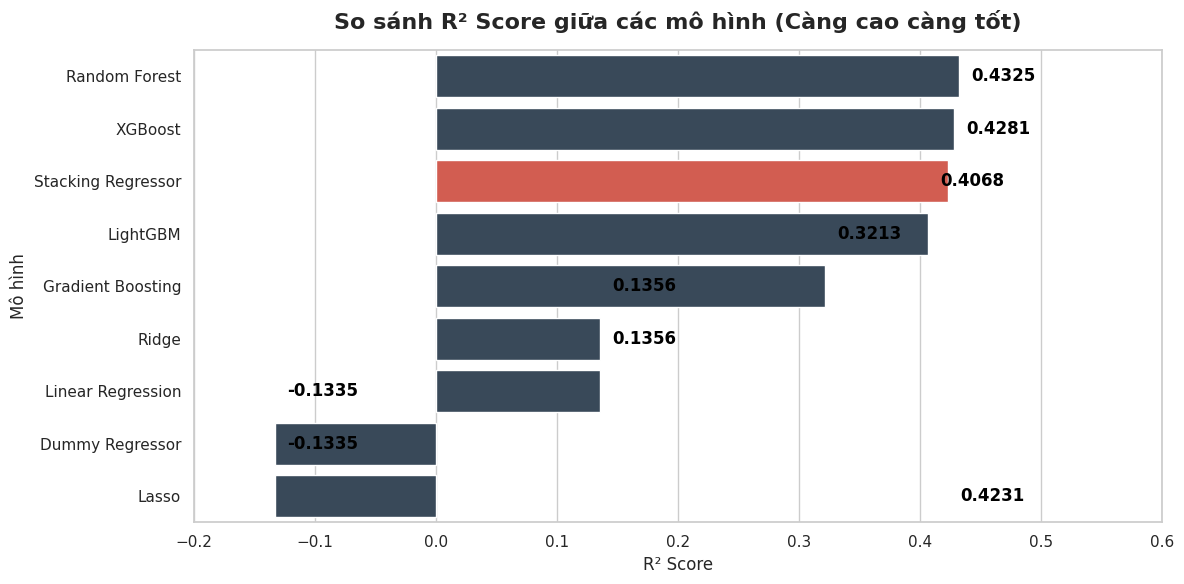

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score

print("======= ĐÁNH GIÁ MÔ HÌNH VÚ KHÍ TỐI THƯỢNG (STACKING) =======")

# 1. Dự đoán trên tập Test bằng mô hình Stacking
pred_stacking_log = stacking_model.predict(X_test)

# Clip giá trị log để tránh lỗi overflow khi expm1
pred_stacking_log_clipped = np.clip(pred_stacking_log, a_min=0, a_max=25)

# Khôi phục về giá trị thực tế (Triệu VNĐ)
pred_stacking_actual = np.expm1(pred_stacking_log_clipped)

# 2. Tính toán các chỉ số lỗi cho Stacking
stacking_mae = mean_absolute_error(y_test_actual, pred_stacking_actual)
stacking_rmse = np.sqrt(mean_squared_error(y_test_actual, pred_stacking_actual))
stacking_median_err = np.median(np.abs(y_test_actual - pred_stacking_actual))
stacking_mape = mean_absolute_percentage_error(y_test_actual, pred_stacking_actual) * 100
stacking_r2 = r2_score(y_test_actual, pred_stacking_actual)

print(f"MAE          :      {stacking_mae:,.2f} (Triệu VNĐ)")
print(f"RMSE         :      {stacking_rmse:,.2f} (Triệu VNĐ)")
print(f"Median Error :      {stacking_median_err:,.2f} (Triệu VNĐ)")
print(f"MAPE         :        {stacking_mape:,.2f}%")
print(f"R² Score     :        {stacking_r2:.4f}")
print("-" * 65)

# 3. Cập nhật vào bảng phân tích lỗi để chuẩn bị vẽ biểu đồ so sánh
# Đọc lại bảng kết quả của 8 mô hình trước đó từ file đã lưu
df_errors_existing = pd.read_excel('./results/model_comparison/error_analysis_summary.xlsx')

# Tạo dòng dữ liệu mới cho Stacking
stacking_metrics = {
    'Model': 'Stacking Regressor',
    'RMSE': stacking_rmse,
    'MAPE (%)': stacking_mape,
    'R2 Score': stacking_r2,
    'Mean Error': stacking_mae,
    'Median Error': stacking_median_err,
    'Max Error': np.max(np.abs(y_test_actual - pred_stacking_actual)),
    'Top 10 Errors': ", ".join([f"{err:,.0f}" for err in np.sort(np.abs(y_test_actual - pred_stacking_actual))[-10:][::-1]])
}

# Thêm Stacking vào bảng và sắp xếp theo R2 Score giảm dần
df_all_models = pd.concat([df_errors_existing, pd.DataFrame([stacking_metrics])], ignore_index=True)
df_all_models = df_all_models.sort_values(by='R2 Score', ascending=False)

# Lưu lại bảng tổng hợp mới bao gồm cả Stacking
df_all_models.to_excel('./results/model_comparison/error_analysis_with_stacking.xlsx', index=False)
print("[SUCCESS] Đã cập nhật kết quả Stacking vào file Excel mới!")

# 4. TRỰC QUAN HÓA: Vẽ biểu đồ so sánh R² Score giữa các mô hình
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Tạo bảng màu, highlight mô hình Stacking bằng màu Đỏ nổi bật, các mô hình khác màu Xanh dịu
colors = ['#e74c3c' if model == 'Stacking Regressor' else '#34495e' for model in df_all_models['Model']]

barplot = sns.barplot(x='R2 Score', y='Model', data=df_all_models, palette=colors)

# Hiển thị giá trị cụ thể lên từng cột
for index, row in df_all_models.iterrows():
    barplot.text(row['R2 Score'] + 0.01, index, f"{row['R2 Score']:.4f}", color='black', va="center", fontweight='bold')

plt.title('So sánh R² Score giữa các mô hình (Càng cao càng tốt)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Mô hình', fontsize=12)
plt.xlim(-0.2, 0.6) # Điều chỉnh giới hạn để hiển thị rõ từ Dummy đến Stacking
plt.tight_layout()

# Lưu biểu đồ vào thư mục kết quả theo cấu trúc dự án
plt.savefig('./results/model_comparison/model_r2_comparison.png', dpi=300)
plt.show()

--- HIỆU NĂNG MÔ HÌNH VŨ KHÍ TỐI THƯỢNG (STACKING) ---
MAE          :      3,808.40 (Triệu VNĐ)
RMSE         :      7,226.13 (Triệu VNĐ)
Median Error :      1,517.51 (Triệu VNĐ)
MAPE         :        209.91%
R² Score     :        0.4231
-----------------------------------------------------------------
\n⏳ Đang tính toán Permutation Importance (Có thể mất 1-2 phút)...


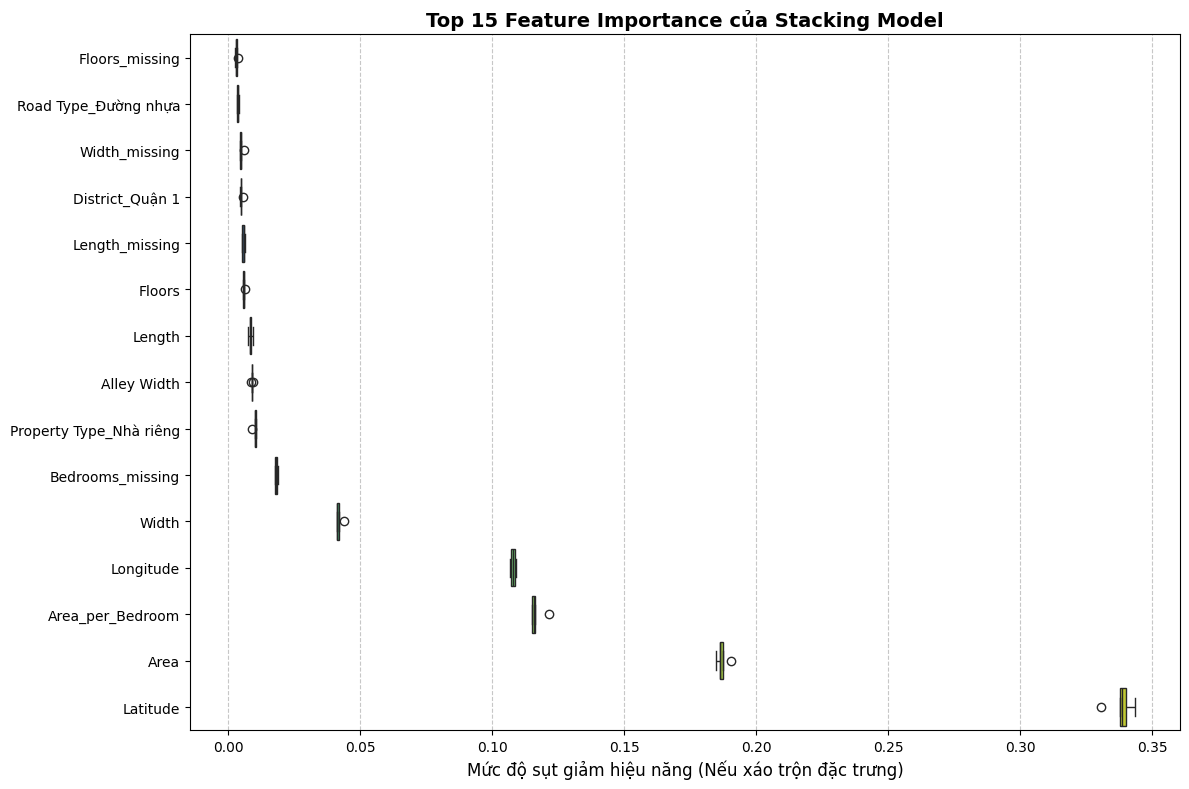

In [8]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dự báo và đánh giá Stacking
log_pred_stack = stacking_model.predict(X_test)
clipped_log_pred_stack = np.clip(log_pred_stack, a_min=0, a_max=25)
actual_pred_stack = np.expm1(clipped_log_pred_stack)

# ĐÃ FIX LỖI: Dùng đúng biến y_test_actual
mae_stack = mean_absolute_error(y_test_actual, actual_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test_actual, actual_pred_stack))
mape_stack = mean_absolute_percentage_error(y_test_actual, actual_pred_stack) * 100
r2_stack = r2_score(y_test_actual, actual_pred_stack)
median_err_stack = np.median(np.abs(y_test_actual - actual_pred_stack))

print(f"--- HIỆU NĂNG MÔ HÌNH VŨ KHÍ TỐI THƯỢNG (STACKING) ---")
print(f"MAE          : {mae_stack:13,.2f} (Triệu VNĐ)")
print(f"RMSE         : {rmse_stack:13,.2f} (Triệu VNĐ)")
print(f"Median Error : {median_err_stack:13,.2f} (Triệu VNĐ)")
print(f"MAPE         : {mape_stack:13.2f}%")
print(f"R² Score     : {r2_stack:13.4f}")
print("-" * 65)

# 2. Đánh giá Tầm quan trọng của Đặc trưng (Permutation Importance)
print("\\n⏳ Đang tính toán Permutation Importance (Có thể mất 1-2 phút)...")
perm_importance = permutation_importance(
    stacking_model, X_test, y_test,
    n_repeats=5, random_state=42,
    scoring='neg_mean_absolute_error'
)

# Trích xuất và Vẽ Boxplot
sorted_idx = perm_importance.importances_mean.argsort()[-15:] # Lấy Top 15

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=perm_importance.importances[sorted_idx].T,
    orient='h',
    palette="viridis"
)
plt.yticks(range(len(sorted_idx)), X_test.columns[sorted_idx])
plt.xlabel("Mức độ sụt giảm hiệu năng (Nếu xáo trộn đặc trưng)", fontsize=12)
plt.title("Top 15 Feature Importance của Stacking Model", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('./results/model_comparison/stacking_feature_importance.png')
plt.show()

In [9]:
# Tạo DataFrame gộp Giá thực tế và Dự đoán của 8 mô hình
# Phần 1: MAE theo phân khúc giá

df_segments = pd.DataFrame({'Actual_Price': y_test_actual})
for name, pred in predictions_dict.items():
    df_segments[name] = pred

# Định nghĩa các mốc phân khúc giá (Đơn vị: Triệu VNĐ)
bins = [0, 3000, 5000, 10000, 20000, np.inf]
labels = ['1. Dưới 3 Tỷ', '2. Từ 3 - 5 Tỷ', '3. Từ 5 - 10 Tỷ', '4. Từ 10 - 20 Tỷ', '5. Trên 20 Tỷ']
df_segments['Segment'] = pd.cut(df_segments['Actual_Price'], bins=bins, labels=labels)

segment_maes = []
for name in predictions_dict.keys():
    for seg in labels:
        mask = df_segments['Segment'] == seg
        if mask.sum() > 0:
            y_true_seg = df_segments.loc[mask, 'Actual_Price']
            y_pred_seg = df_segments.loc[mask, name]
            mae = mean_absolute_error(y_true_seg, y_pred_seg)
            segment_maes.append({'Model': name, 'Segment': seg, 'MAE': mae})

df_segment_mae = pd.DataFrame(segment_maes)
pivot_segment = df_segment_mae.pivot(index='Model', columns='Segment', values='MAE').round(2)
pivot_segment = pivot_segment.sort_values(by='1. Dưới 3 Tỷ')
pivot_segment.to_excel('./results/model_comparison/mae_by_segment.xlsx')
print("[SUCCESS] Đã lưu bảng MAE theo Phân Khúc Giá vào Excel!")
display(pivot_segment)

print("\n--- MAE THEO QUẬN/HUYỆN ---")
district_cols = [col for col in X_test.columns if 'District' in col or 'Quan_' in col or 'Huyen_' in col]

if len(district_cols) > 0:
    districts = X_test[district_cols].idxmax(axis=1)
    districts = districts.str.replace('District_', '').str.replace('Quan_', 'Q').str.replace('Huyen_', 'H')

    df_districts = pd.DataFrame({'Actual_Price': y_test_actual, 'District': districts})
    for name, pred in predictions_dict.items():
        df_districts[name] = pred

    district_maes = []
    for name in predictions_dict.keys():
        for dist in districts.unique():
            mask = df_districts['District'] == dist
            if mask.sum() > 0:
                y_true_dist = df_districts.loc[mask, 'Actual_Price']
                y_pred_dist = df_districts.loc[mask, name]
                mae = mean_absolute_error(y_true_dist, y_pred_dist)
                district_maes.append({'Model': name, 'District': dist, 'MAE': mae})

    df_dist = pd.DataFrame(district_maes)
    pivot_dist = df_dist.pivot(index='Model', columns='District', values='MAE').round(2)
    pivot_dist.to_excel('./results/model_comparison/mae_by_district.xlsx')
    print("[SUCCESS] Đã lưu bảng MAE theo Quận vào Excel!")
    display(pivot_dist.head())
else:
    print("CẢNH BÁO: Không tìm thấy cột nào chứa từ khóa District/Quan/Huyen trong tập X_test.")

[SUCCESS] Đã lưu bảng MAE theo Phân Khúc Giá vào Excel!


Segment,1. Dưới 3 Tỷ,2. Từ 3 - 5 Tỷ,3. Từ 5 - 10 Tỷ,4. Từ 10 - 20 Tỷ,5. Trên 20 Tỷ
Model,,,,,
LightGBM,1416.04,1437.45,2068.27,4127.68,15707.95
XGBoost,1420.47,1550.22,2084.75,4210.80,14708.36
Random Forest,1509.34,1775.57,2094.24,4245.08,14258.72
Gradient Boosting,1682.81,1509.66,1985.62,4504.55,17774.72
Linear Regression,2472.37,1773.10,2527.19,6357.83,19707.72
Ridge,2473.00,1771.52,2524.61,6357.52,19714.88
Dummy Regressor,3915.45,1844.76,1500.51,8435.39,24476.84
Lasso,3915.48,1844.59,1500.60,8435.56,24477.01



--- MAE THEO QUẬN/HUYỆN ---
[SUCCESS] Đã lưu bảng MAE theo Quận vào Excel!


District,Huyện Cần Giờ,Huyện Củ Chi,Huyện Hóc Môn,Huyện Nhà Bè,Quận 1,Quận 10,Quận 11,Quận 12,Quận 2,Quận 3,...,Quận 7,Quận 8,Quận 9,Quận Bình Thạnh,Quận Bình Tân,Quận Gò Vấp,Quận Phú Nhuận,Quận Tân Bình,Quận Tân Phú,TP. Hồ Chí Minh (Mới)
Model,,,,,,,,,,,,,,,,,,,,,
Dummy Regressor,6594.43,7235.17,9613.94,5303.24,12012.38,6890.83,6100.25,7896.82,10984.76,8973.42,...,7126.28,4808.91,6380.93,8545.39,5329.60,5183.64,3437.06,7440.86,5166.05,5755.92
Gradient Boosting,4885.65,4973.80,6164.61,4121.63,8648.63,5473.47,3796.13,5675.85,7023.70,6205.40,...,5179.89,3905.30,4857.62,5396.50,3764.36,3386.27,2458.70,5366.47,3573.73,3676.87
Lasso,6594.41,7236.52,9614.00,5303.21,12012.50,6890.87,6100.24,7896.85,10984.78,8973.47,...,7126.34,4808.82,6380.91,8545.44,5329.61,5183.69,3437.09,7440.90,5166.09,5755.90
LightGBM,4787.02,4845.79,5561.23,4060.73,7628.90,4366.26,3850.95,5136.23,5977.06,4834.06,...,4733.48,3799.50,4615.98,4184.77,3505.92,2686.63,2228.01,4689.27,3425.42,3294.63
Linear Regression,4838.45,5441.22,6485.90,4236.39,10425.16,6206.65,4165.93,5932.85,7854.19,6644.69,...,6222.33,3846.72,5297.32,6669.18,4578.05,4525.21,2814.90,6101.04,4575.19,4917.73


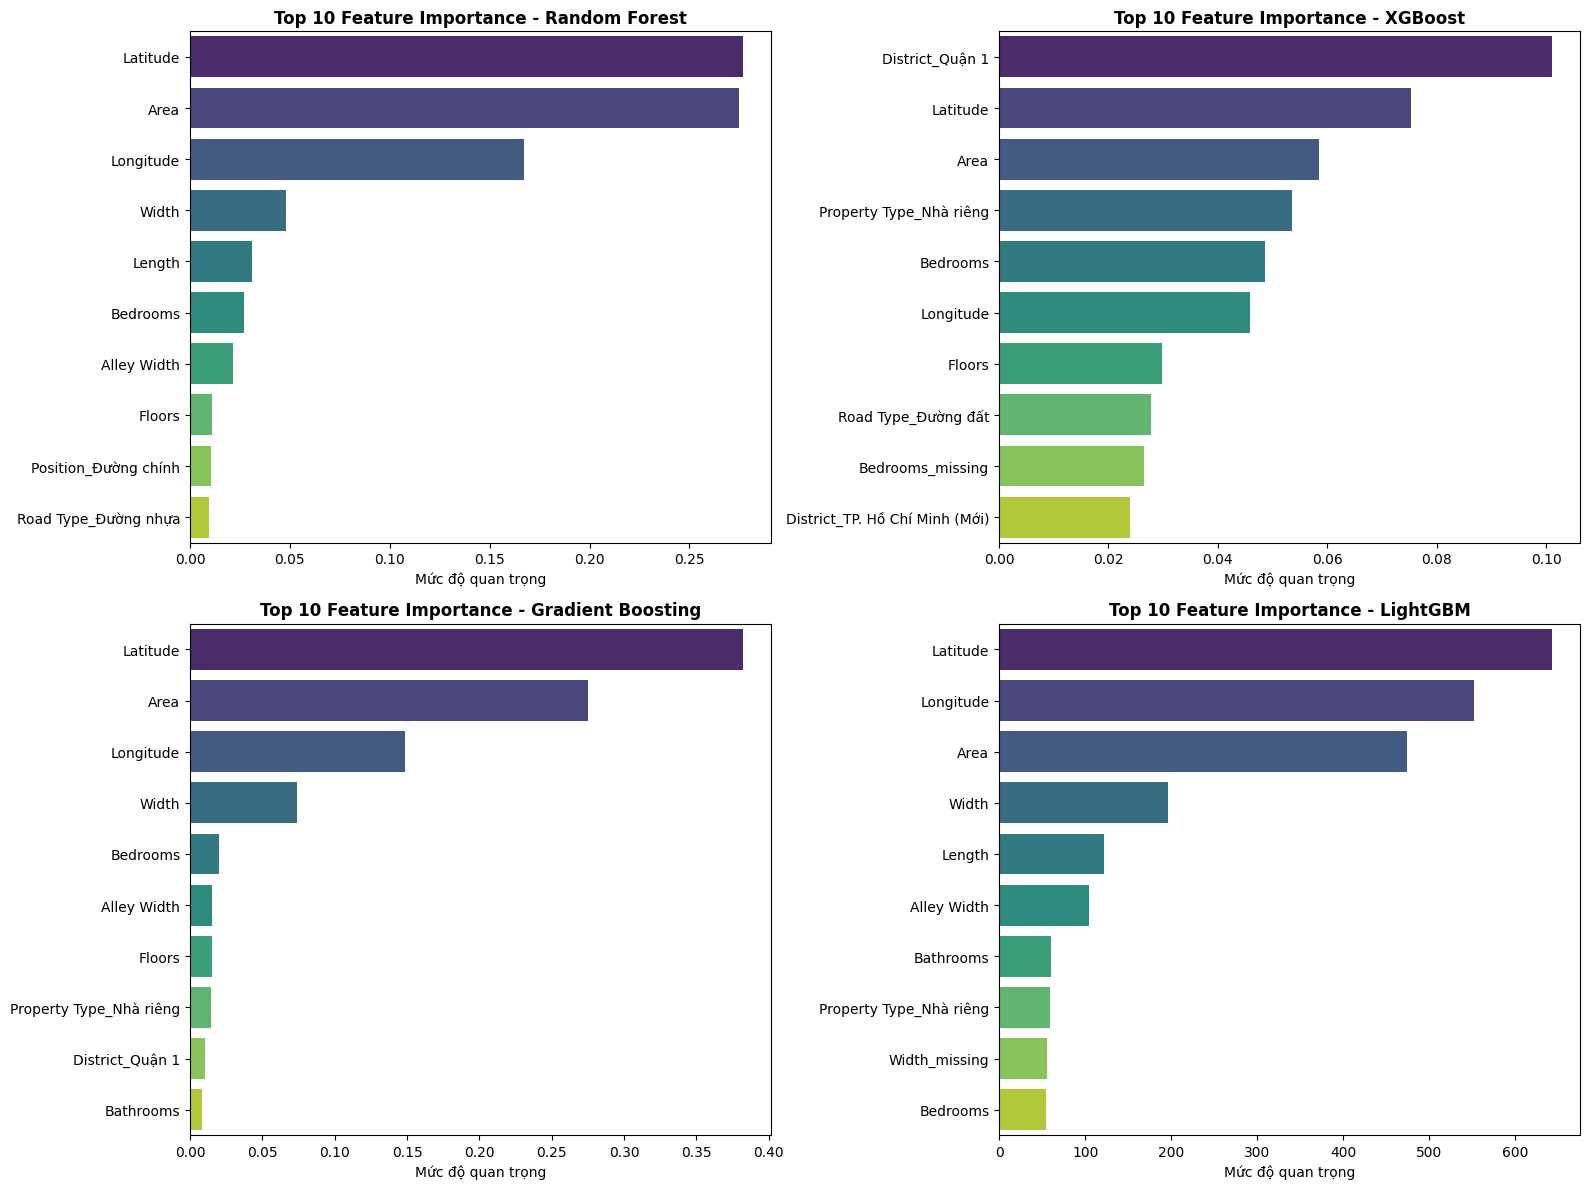

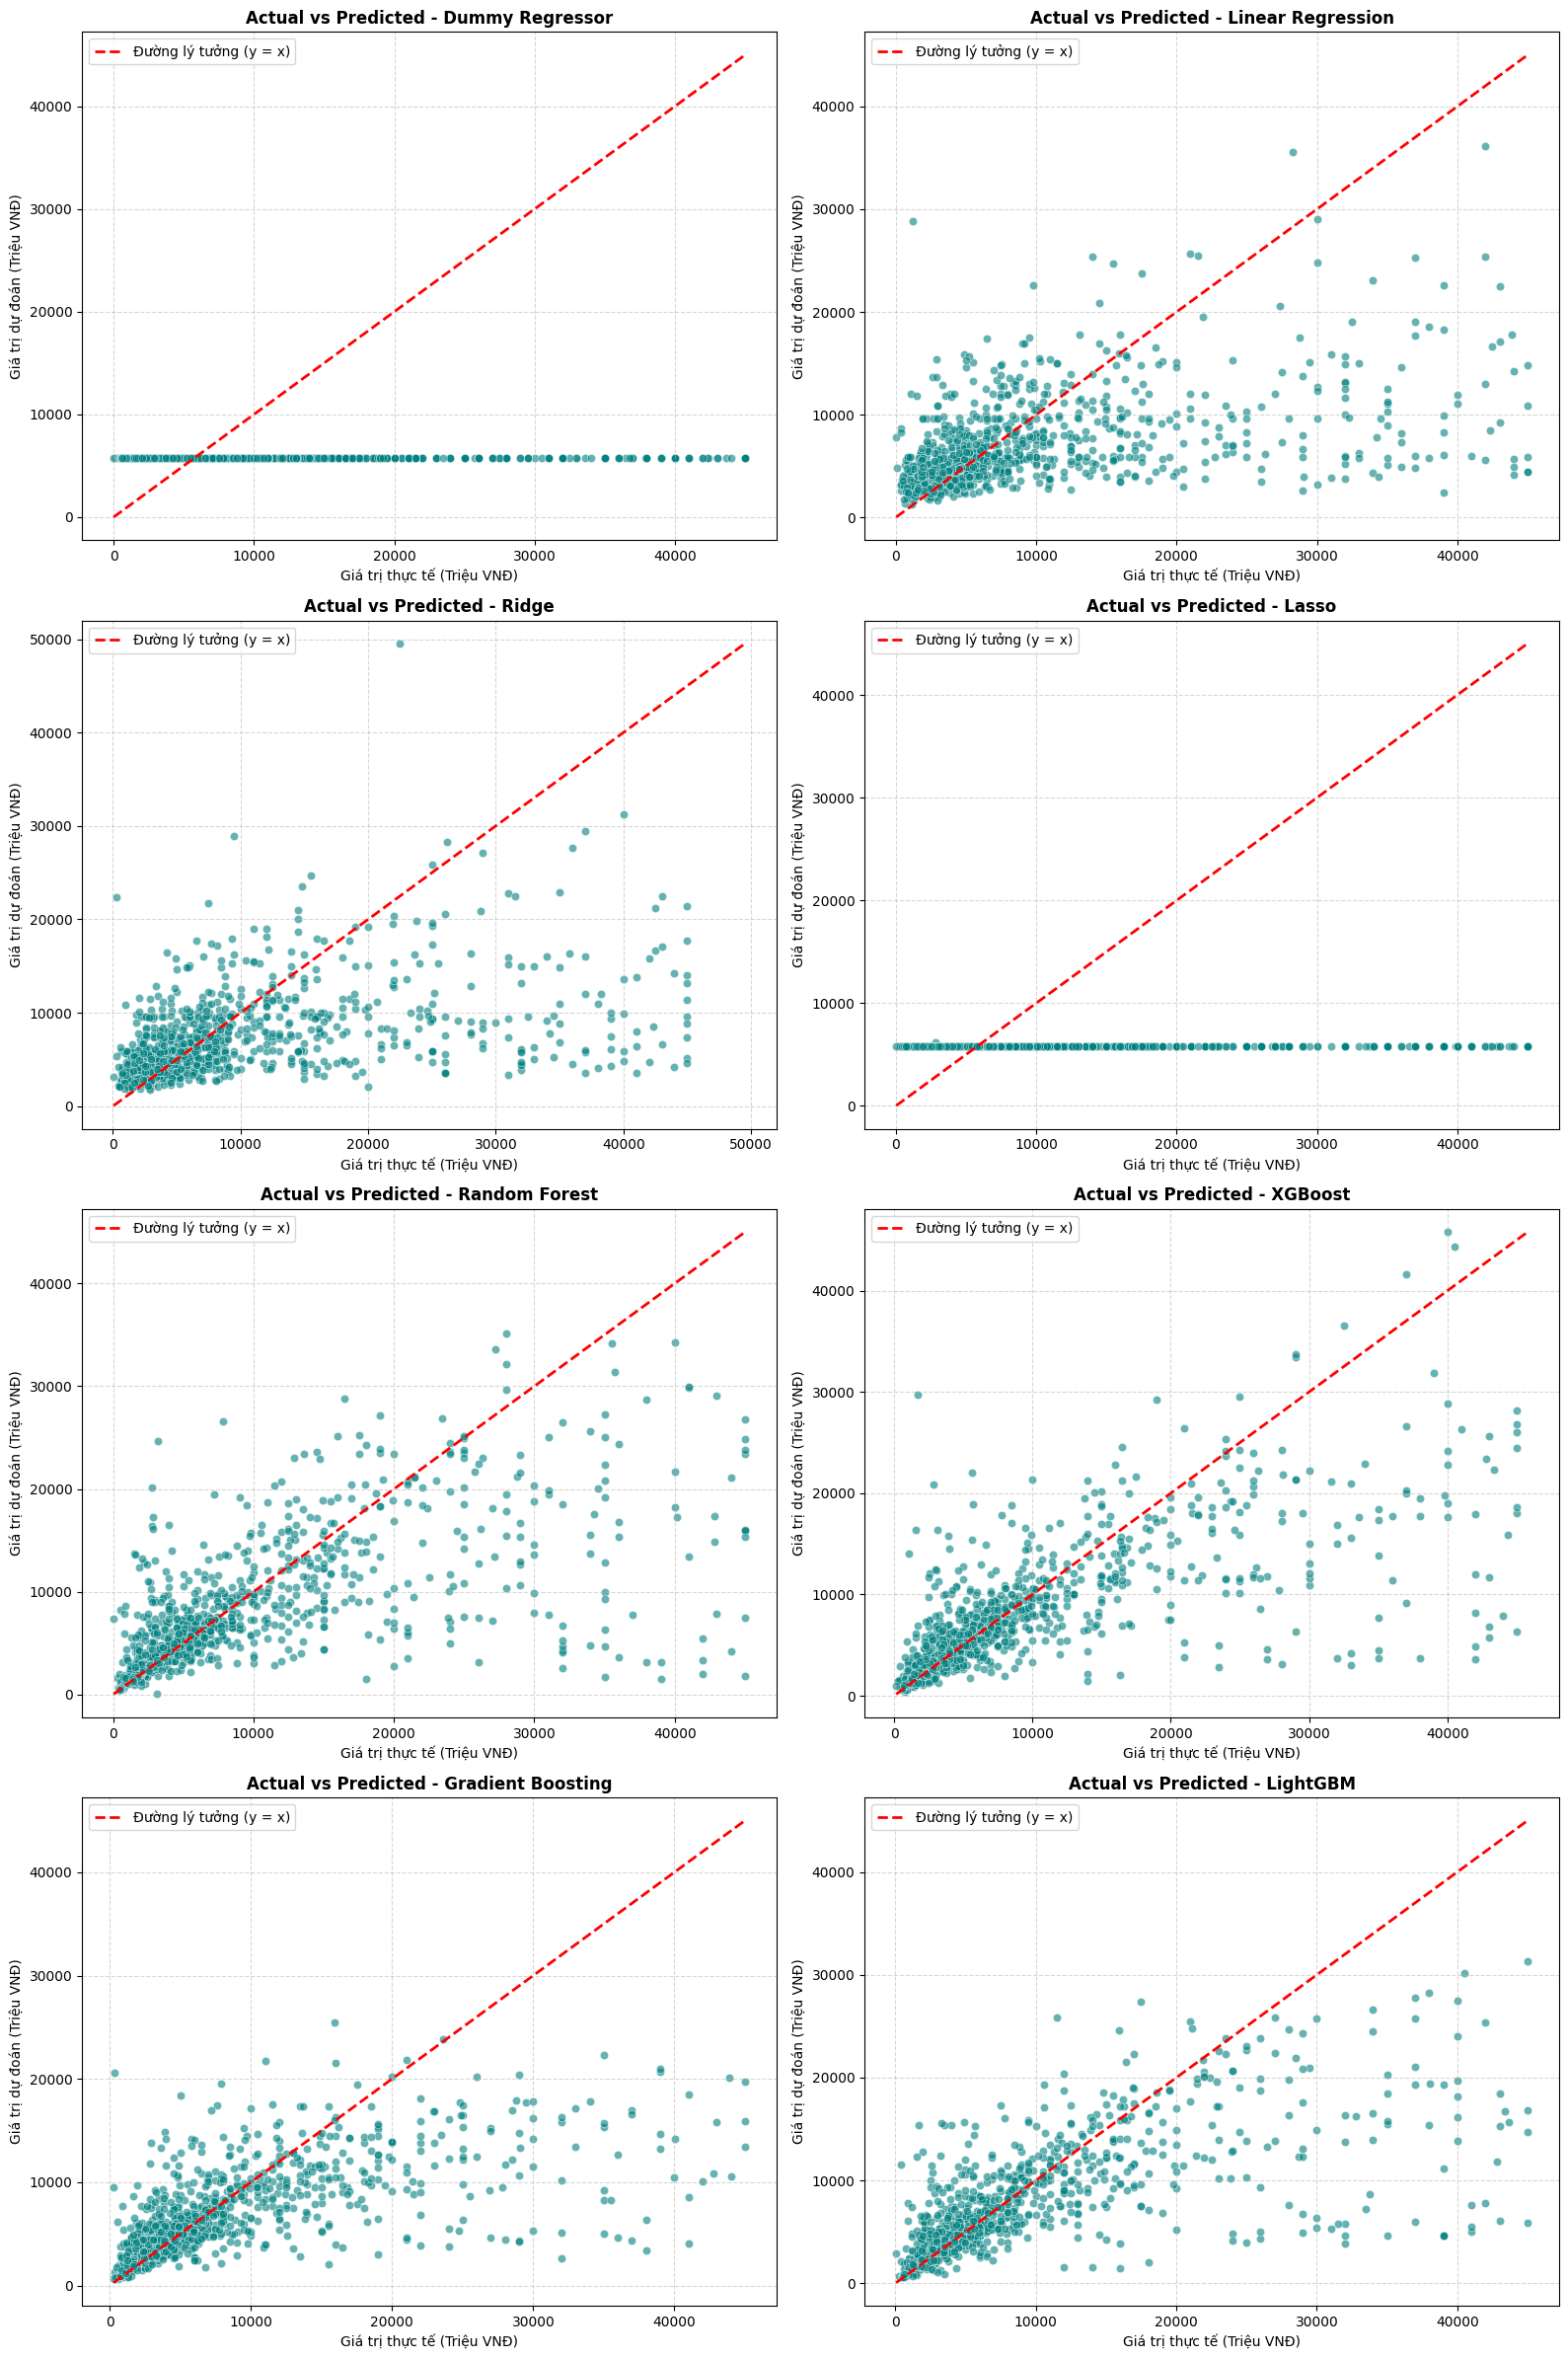

--- ĐÁNH GIÁ CLIPPING: Linear Regression ---
Số lượng dự báo bị Clipping (>25): 0
MAE TRƯỚC Clipping: 5,203.75 (Triệu VNĐ)
MAE SAU Clipping  : 5,203.75 (Triệu VNĐ)

--- ĐÁNH GIÁ CLIPPING: XGBoost ---
Số lượng dự báo bị Clipping (>25): 0
MAE TRƯỚC Clipping: 3,780.46 (Triệu VNĐ)
MAE SAU Clipping  : 3,780.46 (Triệu VNĐ)



In [12]:
# Gộp biểu đồ quan trọng nhất vào một cell để notebook ngắn hơn
# Phần 1: Top 10 Feature Importance của 4 mô hình mạnh nhất
advanced_models = {
    'Random Forest': all_models['Random Forest'],
    'XGBoost': all_models['XGBoost'],
    'Gradient Boosting': all_models['Gradient Boosting'],
    'LightGBM': all_models['LightGBM']
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Get the original feature names before feature engineering
# These are the features that 'advanced_models' were trained on.
original_feature_names = train_df.drop(columns=[target_col]).columns

for idx, (name, model) in enumerate(advanced_models.items()):
    importances = model.feature_importances_
    # Use the original feature names that match the length of importances
    feature_names_for_plot = original_feature_names

    df_importance = pd.DataFrame({
        'Feature': feature_names_for_plot,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    sns.barplot(
        x='Importance',
        y='Feature',
        data=df_importance,
        ax=axes[idx],
        palette='viridis',
        hue='Feature',
        legend=False
    )
    axes[idx].set_title(f'Top 10 Feature Importance - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Mức độ quan trọng')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.savefig('./results/model_comparison/top_10_feature_importance.png', dpi=300)
plt.show()

# Phần 2: Actual vs Predicted cho cả 8 mô hình
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, (name, pred_actual) in enumerate(predictions_dict.items()):
    sample_size = min(1000, len(y_test_actual))
    sample_idx = np.random.choice(len(y_test_actual), sample_size, replace=False)

    actual_sampled = y_test_actual.iloc[sample_idx] if isinstance(y_test_actual, pd.Series) else y_test_actual[sample_idx]
    pred_sampled = pred_actual[sample_idx]

    sns.scatterplot(x=actual_sampled, y=pred_sampled, alpha=0.6, ax=axes[idx], color='teal')

    max_val = max(actual_sampled.max(), pred_sampled.max())
    min_val = min(actual_sampled.min(), pred_sampled.min())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường lý tưởng (y = x)')

    axes[idx].set_title(f'Actual vs Predicted - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Giá trị thực tế (Triệu VNĐ)')
    axes[idx].set_ylabel('Giá trị dự đoán (Triệu VNĐ)')
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('./results/model_comparison/actual_vs_predicted.png', dpi=300)
plt.show()

# Phần 3: Đánh giá clipping trên các mô hình tiêu biểu
from sklearn.metrics import mean_absolute_error

def evaluate_clipping(model_name, model, X_test_eval, y_test_actual):
    raw_log_pred = model.predict(X_test_eval)
    num_clipped = np.sum(raw_log_pred > 25)

    try:
        with np.errstate(over='ignore'):
            raw_actual_pred = np.expm1(raw_log_pred)
            valid_mask = np.isfinite(raw_actual_pred)
            mae_before = mean_absolute_error(y_test_actual[valid_mask], raw_actual_pred[valid_mask])
            if not np.all(valid_mask):
                print(f"  [!] Có {np.sum(~valid_mask)} giá trị bị tràn số tới vô cực (inf) trước clipping.")
    except Exception:
        mae_before = float('inf')

    clipped_log_pred = np.clip(raw_log_pred, a_min=0, a_max=25)
    clipped_actual_pred = np.expm1(clipped_log_pred)
    mae_after = mean_absolute_error(y_test_actual, clipped_actual_pred)

    print(f"--- ĐÁNH GIÁ CLIPPING: {model_name} ---")
    print(f"Số lượng dự báo bị Clipping (>25): {num_clipped}")
    print(f"MAE TRƯỚC Clipping: {mae_before:,.2f} (Triệu VNĐ)")
    print(f"MAE SAU Clipping  : {mae_after:,.2f} (Triệu VNĐ)\n")

# Create a non-feature-engineered X_test specifically for models trained on 59 features
X_test_original = test_df.drop(columns=[target_col])

evaluate_clipping("Linear Regression", all_models["Linear Regression"], X_test_original, y_test_actual)
evaluate_clipping("XGBoost", all_models["XGBoost"], X_test_original, y_test_actual)
